Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error

Load the Dataset

In [2]:
data = pd.read_csv("bikes.csv")

In [3]:
df = data.copy()

Initial Data Inspection
• Shape of dataset
• Column names
• Data types
• First & last few rows

In [4]:
df.shape

(7857, 8)

In [5]:
df.columns

Index(['model_name', 'model_year', 'kms_driven', 'owner', 'location',
       'mileage', 'power', 'price'],
      dtype='object')

In [6]:
df.dtypes

model_name    object
model_year     int64
kms_driven    object
owner         object
location      object
mileage       object
power         object
price          int64
dtype: object

In [7]:
df.head()

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


In [8]:
df.tail()

,model_name,model_year,kms_driven,owner,location,mileage,power,price
7852,Yamaha YZF-R15 150cc 2011,2011,7000 Km,first owner,agra,\n\n 42 kmpl,16 bhp,55000
7853,Bajaj Discover 100cc 2015,2015,Mileage 80 Kmpl,first owner,delhi,\n\n 80 Kmpl,7.7,28000
7854,Bajaj Pulsar 180cc 2016,2016,6407 Km,first owner,bangalore,\n\n 65 kmpl,17 bhp,61740
7855,Bajaj V15 150cc 2016,2016,7524 Km,first owner,bangalore,\n\n 57 kmpl,11.80 bhp,49000
7856,Bajaj Pulsar 220cc 2016,2016,15000 Km,first owner,chennai,\n\n 38 kmpl,21 bhp,65000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB


Handling Missing Values
• Identify null values
• Decision: drop / fill / keep

In [10]:
df.isnull().sum()

model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

Brand & Model Feature Engineering

In [12]:
df['model_name'] = df['model_name'].str.strip()

In [13]:
brands = [i.split()[0] for i in df.model_name]

In [14]:
df['brand'] = brands 

In [15]:
df

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500,Bajaj
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000,Royal
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000,Hyosung
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000,Bajaj
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500,Jawa
...,...,...,...,...,...,...,...,...,...
7852,Yamaha YZF-R15 150cc 2011,2011,7000 Km,first owner,agra,\n\n 42 kmpl,16 bhp,55000,Yamaha
7853,Bajaj Discover 100cc 2015,2015,Mileage 80 Kmpl,first owner,delhi,\n\n 80 Kmpl,7.7,28000,Bajaj
7854,Bajaj Pulsar 180cc 2016,2016,6407 Km,first owner,bangalore,\n\n 65 kmpl,17 bhp,61740,Bajaj
7855,Bajaj V15 150cc 2016,2016,7524 Km,first owner,bangalore,\n\n 57 kmpl,11.80 bhp,49000,Bajaj


In [16]:
# Clean Numerical Columns

Preprocessing kms_driven col

In [17]:
df['kms_driven'] = df['kms_driven'].apply(lambda x: str(x).lower().replace('km','').strip())

In [18]:
df['kms_driven']

0               17000
1               50000
2               14795
3        mileage 28 s
4                2000
            ...      
7852             7000
7853    mileage 80 pl
7854             6407
7855             7524
7856            15000
Name: kms_driven, Length: 7857, dtype: object

In [19]:
df['kms_driven'] = df['kms_driven'].apply(lambda x: np.nan if str(x).startswith("mileage") else x)

In [20]:
df['kms_driven']

0       17000
1       50000
2       14795
3         NaN
4        2000
        ...  
7852     7000
7853      NaN
7854     6407
7855     7524
7856    15000
Name: kms_driven, Length: 7857, dtype: object

In [21]:
df['kms_driven'] = df['kms_driven'].apply(lambda x: np.nan if str(x).lower().startswith("yes") else x)

In [22]:
df['kms_driven']

0       17000
1       50000
2       14795
3         NaN
4        2000
        ...  
7852     7000
7853      NaN
7854     6407
7855     7524
7856    15000
Name: kms_driven, Length: 7857, dtype: object

In [23]:
df.isna().sum()

model_name       0
model_year       0
kms_driven    1988
owner            0
location        19
mileage         11
power           31
price            0
brand            0
dtype: int64

In [24]:
df['kms_driven'] = pd.to_numeric(df['kms_driven'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  7857 non-null   object 
 1   model_year  7857 non-null   int64  
 2   kms_driven  5869 non-null   float64
 3   owner       7857 non-null   object 
 4   location    7838 non-null   object 
 5   mileage     7846 non-null   object 
 6   power       7826 non-null   object 
 7   price       7857 non-null   int64  
 8   brand       7857 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 552.6+ KB


In [26]:
df['kms_driven'] = df['kms_driven'].fillna(df['kms_driven'].mean().round(2))

In [27]:
df['kms_driven']

0       17000.00
1       50000.00
2       14795.00
3       23090.12
4        2000.00
          ...   
7852     7000.00
7853    23090.12
7854     6407.00
7855     7524.00
7856    15000.00
Name: kms_driven, Length: 7857, dtype: float64

In [28]:
avg_price = df.loc[df["price"] != 0, "price"].mean()
df.loc[df["price"] == 0, "price"] = avg_price

C:\Users\PC\AppData\Local\Temp\ipykernel_19092\2484187067.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '107214.3539483772' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["price"] == 0, "price"] = avg_price


In [29]:
df

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand
0,Bajaj Avenger Cruise 220 2017,2017,17000.00,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500.0,Bajaj
1,Royal Enfield Classic 350cc 2016,2016,50000.00,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000.0,Royal
2,Hyosung GT250R 2012,2012,14795.00,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000.0,Hyosung
3,Bajaj Dominar 400 ABS 2017,2017,23090.12,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000.0,Bajaj
4,Jawa Perak 330cc 2020,2020,2000.00,first owner,bangalore,\n\n,30 bhp,197500.0,Jawa
...,...,...,...,...,...,...,...,...,...
7852,Yamaha YZF-R15 150cc 2011,2011,7000.00,first owner,agra,\n\n 42 kmpl,16 bhp,55000.0,Yamaha
7853,Bajaj Discover 100cc 2015,2015,23090.12,first owner,delhi,\n\n 80 Kmpl,7.7,28000.0,Bajaj
7854,Bajaj Pulsar 180cc 2016,2016,6407.00,first owner,bangalore,\n\n 65 kmpl,17 bhp,61740.0,Bajaj
7855,Bajaj V15 150cc 2016,2016,7524.00,first owner,bangalore,\n\n 57 kmpl,11.80 bhp,49000.0,Bajaj


Preprocessing mileage col

eature Cleaning & Standardization

In [30]:
m_list = df['mileage'].to_list()

In [31]:
m_list = [str(i).lower().replace("kmpl","") for i in m_list]
m_list = [str(i).lower().replace("kms","") for i in m_list]
m_list = [str(i).lower().replace("\n","") for i in m_list]
m_list = [str(i).lower().replace("liquid cooled","37.6") for i in m_list]
m_list = [str(i).lower().split("-")[0] for i in m_list]
m_list = [str(i).strip() for i in m_list]

In [32]:
df['mileage'] = m_list

In [33]:
np.unique(df.mileage)

array(['', '104', '12', '12.5', '13', '14', '15', '16', '17', '17.85',
       '18', '18.86', '19', '20', '20.3', '20.40', '21', '22', '23', '25',
       '26', '27', '28', '29', '30', '31.85', '32', '35', '37', '37.6',
       '38', '38.5', '39.1', '39.4', '40', '42', '43', '45', '45.8',
       '46.40', '48', '5', '50', '52', '53', '53.72', '54', '55', '55.47',
       '56', '57', '58', '59', '60', '62', '63', '63.97', '64', '65',
       '67', '68', '69', '70', '71', '72', '74', '75', '77', '80', '81',
       '82', '82.4', '83', '84', '85', '89', '90', '95', '96.9', 'nan'],
      dtype=object)

In [34]:
df[df['mileage'] == 'nan']

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand
144,TVS Apache RTR 160cc 2014,2014,20372.0,first owner,delhi,nan,15.2 bhp @ 8500 rpm,42000.0,TVS
193,Hero Karizma R 223cc 2010,2010,70000.0,first owner,noida,nan,"17 bhp @ 7,000 rpm",19215.0,Hero
422,TVS Apache 150cc 2007,2007,36486.0,second owner,bathinda,nan,13.7 Bhp @ 8500 rpm,19500.0,TVS
1376,KTM RC 390cc 2015,2015,28000.0,second owner,hyderabad,nan,"43 bhp @ 9,000 rpm",130000.0,KTM
1488,Royal Enfield Thunderbird 350cc 2015,2015,24000.0,first owner,bangalore,nan,"19.80 bhp @ 5,250 rpm",115000.0,Royal
1640,Kawasaki Ninja 650cc 2020,2020,8000.0,second owner,delhi,nan,"66.4 bhp @ 8,000 rpm",520000.0,Kawasaki
2160,Harley-Davidson Street Rod 2019,2019,600.0,first owner,bangalore,nan,70 bhp,700700.0,Harley-Davidson
2277,KTM Duke 200cc 2012,2012,30000.0,first owner,bangalore,nan,"25 bhp @ 10,000 rpm",85000.0,KTM
4646,Hero Passion Pro 100cc 2014,2014,16834.0,first owner,chandigarh,nan,8.2 Bhp @ 8000 rpm,40000.0,Hero
4655,Bajaj Pulsar 180cc 2013,2013,82000.0,first owner,chandigarh,nan,"15 bhp @ 9,000 rpm",40000.0,Bajaj


In [35]:
df.loc[144,'mileage'] = '45'
df.loc[193,'mileage'] = '30'
df.loc[422,'mileage'] = '40'
df.loc[1376,'mileage'] = '30'
df.loc[1488,'mileage'] = '30'
df.loc[1640,'mileage'] = '20'
df.loc[2160,'mileage'] = '13'
df.loc[2277,'mileage'] = '30'
df.loc[4646,'mileage'] = '84'
df.loc[4655,'mileage'] = '40'
df.loc[7394,'mileage'] = '40'

In [36]:
df[df['mileage'] == 'nan']

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand


In [37]:
df[df['mileage'] == '']

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand
4,Jawa Perak 330cc 2020,2020,2000.0,first owner,bangalore,,30 bhp,197500.0,Jawa
40,Bajaj Discover 110cc 2019,2019,45000.0,first owner,chittorgarh,,8.60 bhp,46000.0,Bajaj
50,Royal Enfield Bullet 350cc 2019,2019,27300.0,first owner,hyderabad,,19.80 bhp,130000.0,Royal
62,Royal Enfield Thunderbird X 350cc ABS 2019,2019,9000.0,first owner,mumbai,,19.80 bhp,166000.0,Royal
63,TVS Apache RTR 160 4V DISC ABS 2019,2019,21500.0,first owner,hyderabad,,16.1 bhp,93000.0,TVS
...,...,...,...,...,...,...,...,...,...
7815,Honda Livo 110cc 2019,2019,15492.0,first owner,jaipur,,8.25 Bhp,53214.0,Honda
7816,Bajaj Discover 135cc 2010,2010,21728.0,first owner,chennai,,9.64 kw,16000.0,Bajaj
7832,Bajaj Discover 135cc 2009,2009,18000.0,first owner,delhi,,9.64 kw,21000.0,Bajaj
7837,Bajaj Discover 135cc 2009,2009,25000.0,first owner,delhi,,9.64 kw,22000.0,Bajaj


In [38]:
df['mileage'] = (df['mileage'].replace('', 0))

In [39]:
df[df['mileage'] == 0]

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand
4,Jawa Perak 330cc 2020,2020,2000.0,first owner,bangalore,0,30 bhp,197500.0,Jawa
40,Bajaj Discover 110cc 2019,2019,45000.0,first owner,chittorgarh,0,8.60 bhp,46000.0,Bajaj
50,Royal Enfield Bullet 350cc 2019,2019,27300.0,first owner,hyderabad,0,19.80 bhp,130000.0,Royal
62,Royal Enfield Thunderbird X 350cc ABS 2019,2019,9000.0,first owner,mumbai,0,19.80 bhp,166000.0,Royal
63,TVS Apache RTR 160 4V DISC ABS 2019,2019,21500.0,first owner,hyderabad,0,16.1 bhp,93000.0,TVS
...,...,...,...,...,...,...,...,...,...
7815,Honda Livo 110cc 2019,2019,15492.0,first owner,jaipur,0,8.25 Bhp,53214.0,Honda
7816,Bajaj Discover 135cc 2010,2010,21728.0,first owner,chennai,0,9.64 kw,16000.0,Bajaj
7832,Bajaj Discover 135cc 2009,2009,18000.0,first owner,delhi,0,9.64 kw,21000.0,Bajaj
7837,Bajaj Discover 135cc 2009,2009,25000.0,first owner,delhi,0,9.64 kw,22000.0,Bajaj


In [40]:
df['mileage'] = pd.to_numeric(df['mileage'] )

In [41]:
# m = df.groupby('brand')['mileage'].mean().to_dict()

In [42]:
# m

In [43]:
null_brands = np.unique(df[df['mileage'] == 0].brand)

In [44]:
# null_brands

In [45]:
for brand in null_brands:
    values = df[df.brand == brand].mileage.to_numpy()
    values = np.delete(values,np.where(values == '0'))
    if(len(values) == 0):
        print(brand)
        mean=0
    else:
        mean = values.astype("float32").mean()
    for index,rows in df[df.brand == brand].iterrows():
        if df.iloc[index,df.columns.get_loc("mileage")] == 0.0:
            df.iloc[index,df.columns.get_loc("mileage")] = mean

In [46]:
df[df['mileage'] == 0.0]

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand
2023,BMW G 310 R 2018,2018,8500.0,first owner,mumbai,0.0,33 bhp,260000.0,BMW
2638,Ideal Jawa Yezdi Delux 250 cc 1978,1978,85000.0,first owner,chikamaglur,0.0,NaN,100000.0,Ideal
2832,BMW G 310 R 2019,2019,9000.0,first owner,mumbai,0.0,33 bhp,270000.0,BMW
3400,BMW G 310 R 2019,2019,1500.0,first owner,chandigarh,0.0,33 bhp,240000.0,BMW
3773,Fb Mondial HPS 300 250cc 2020,2020,4000.0,first owner,hyderabad,0.0,24.5 bhp,341700.0,Fb
3827,BMW G 310 R 2019,2019,1200.0,first owner,patna,0.0,33 bhp,277500.0,BMW
4154,BMW G 310 GS 2019,2019,22000.0,first owner,kalyan,0.0,33 bhp,299000.0,BMW
4392,BMW G 310 GS 2018,2018,10000.0,first owner,mumbai,0.0,33 bhp,290000.0,BMW
5031,Fb Mondial HPS 300 250cc 2019,2019,3100.0,first owner,kukatpally,0.0,24.5 bhp,300000.0,Fb
5435,BMW G 310 R 2019,2019,12872.0,first owner,pune,0.0,33 bhp,270000.0,BMW


In [47]:
df.loc[2023,'mileage'] = 30.0
df.loc[2638,'mileage'] = 30.0
df.loc[2832,'mileage'] = 30.0
df.loc[3400,'mileage'] = 30.0
df.loc[3773,'mileage'] = 30.0
df.loc[3827,'mileage'] = 30.0
df.loc[4154,'mileage'] = 30.0
df.loc[4392,'mileage'] = 30.0
df.loc[5031,'mileage'] = 30.0
df.loc[5435,'mileage'] = 30.0
df.loc[5584,'mileage'] = 23.0
df.loc[5586,'mileage'] = 16.0
df.loc[5527,'mileage'] = 28.0
df.loc[5727,'mileage'] = 28.0
df.loc[6561,'mileage'] = 28.0
df.loc[7306,'mileage'] = 50.0

In [48]:
df[df['mileage'] == 0.0]

,model_name,model_year,kms_driven,owner,location,mileage,power,price,brand


Preprocessing Power

In [49]:
df['power'].isnull().sum()

np.int64(31)

In [50]:
# df['power'].to_list()

In [51]:
x = df['power'].isna()

In [52]:
np.where(x == True)

(array([ 135, 1627, 1691, 1716, 2442, 2487, 2638, 2659, 2714, 2819, 3088,
        3977, 4393, 4425, 4591, 4760, 5626, 5673, 5694, 5788, 5950, 6155,
        6321, 6781, 6853, 7306, 7442, 7513, 7783, 7796, 7801]),)

In [53]:
print(df.loc[135,'model_name'])
print(df.loc[1627,'model_name'])
print(df.loc[1691,'model_name']) 
print(df.loc[1716,'model_name']) 
print(df.loc[2442,'model_name']) 
print(df.loc[2487,'model_name']) 
print(df.loc[2638,'model_name'])  
print(df.loc[2659,'model_name']) 
print(df.loc[2714,'model_name']) 
print(df.loc[2819,'model_name'])  
print(df.loc[3088,'model_name'])  
print(df.loc[3977,'model_name'])  
print(df.loc[4393,'model_name'])  
print(df.loc[4425,'model_name'])  
print(df.loc[4291,'model_name'])
print(df.loc[4591,'model_name'])
print(df.loc[4760,'model_name'])  
print(df.loc[5626,'model_name']) 
print(df.loc[5673,'model_name'])  
print(df.loc[5694,'model_name'])  
print(df.loc[5788,'model_name'])  
print(df.loc[5950,'model_name'])  
print(df.loc[6155,'model_name'])  
print(df.loc[6321,'model_name']) 
print(df.loc[6781,'model_name'])  
print(df.loc[6853,'model_name'])
print(df.loc[7306,'model_name'])  
print(df.loc[7442,'model_name'])  
print(df.loc[7513,'model_name'])  
print(df.loc[7783,'model_name']) 
print(df.loc[7796,'model_name']) 
print(df.loc[7801,'model_name']) 

Hyosung GD250R 2021
Yamaha RX-Z 135cc 1999
Royal Enfield Bullet 350 cc 1982
Royal Enfield Bullet 350 cc 1982
Harley-Davidson Low Rider 1750cc 2019
Royal Enfield Bullet 350 cc 1982
Ideal Jawa Yezdi Delux 250 cc 1978
Harley-Davidson Street Bob 2012
Royal Enfield Bullet 350 cc 1982
Harley-Davidson Low Rider 1750cc 2018
Royal Enfield Bullet 350 cc 1982
Benelli 302S 2021
Royal Enfield Bullet 350 cc 1982
Triumph Street Triple S 2018
Yamaha FZS-FI V 3.0 150cc 2020
Harley-Davidson Breakout 2016
Royal Enfield Bullet 350 cc 1982
Harley-Davidson Roadster 2017
Harley-Davidson CVO 2012
Harley-Davidson Roadster 2018
Hero Ignitor 125cc 2012
Hyosung Aquila 250 250cc 2015
Hero Xtreme Sports 149cc 2015
Hyosung Aquila 250 250cc 2015
Benelli TNT 25 250 cc 2016
Hero Xtreme Sports 149cc 2016
yamaha Libero 110cc 2006
Hero Splendor Plus 100 CC 2014
Bajaj Pulsar NS 200cc 2011
Bajaj Pulsar 200cc 2013
Hero Splendor Plus 100 CC 2014
Hero i Smart 125cc 2016


In [54]:
df.loc[135,'power'] = '27.6'
df.loc[1627,'power'] = '14.0'
df.loc[1691,'power'] = '18.0'
df.loc[1716,'power'] = '18.0'
df.loc[2442,'power'] = '86.0'
df.loc[2487,'power'] = '8.0'
df.loc[2638,'power'] = '13.0'
df.loc[2659,'power'] = '91.0'
df.loc[2714,'power'] = '18.0'
df.loc[2819,'power'] = '76.0'
df.loc[3088,'power'] = '18.0'
df.loc[3977,'power'] = '29.6'
df.loc[4393,'power'] = '18.0'
df.loc[4425,'power'] = '111.0'
df.loc[4591,'power'] = '73.0'
df.loc[4291,'power'] = '12.2'
df.loc[4760,'power'] = '18.0'
df.loc[5626,'power'] = '66.0'
df.loc[5673,'power'] = '75.0'
df.loc[5694,'power'] = '67.0'
df.loc[5788,'power'] = '90.5'
df.loc[5950,'power'] = '66.0'
df.loc[6155,'power'] = '11.0'
df.loc[6321,'power'] = '26.12'
df.loc[6781,'power'] = '15.6'
df.loc[6853,'power'] = '26.21'
df.loc[7306,'power'] = '26.15'
df.loc[7442,'power'] = '15.6'
df.loc[7513,'power'] = '23.5'
df.loc[7783,'power'] = '23.17'
df.loc[7796,'power'] = '8.0'
df.loc[7801,'power'] = '8.2'

In [55]:
df['power'].isna().sum()

np.int64(0)

In [56]:
df['power'] = df['power'].apply(lambda x: str(x).lower().replace('bhp','').strip())

In [57]:
df['power'] = df['power'].apply(lambda x: str(x).lower().replace('ps','').strip())

In [58]:
df['power'] = df['power'].apply(lambda x: str(x).lower().replace('kw','').strip())

In [59]:
df['power'] = df['power'].apply(lambda x: str(x).lower().replace('hp','').strip())

In [60]:
df['power'] = df['power'].apply(lambda x: str(x).split(" ")[0])

In [61]:
df['power'] = df['power'].apply(lambda x: str(x).split("-")[0])

In [62]:
df['power'] = df['power'].astype(float)

In [63]:
# df['power'].to_list()

In [64]:
df.isna().sum()

model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage        0
power          0
price          0
brand          0
dtype: int64

Preprocessing location

In [65]:
df['location'].mode()

0    delhi
Name: location, dtype: object

In [66]:
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [67]:
df.isna().sum()

model_name    0
model_year    0
kms_driven    0
owner         0
location      0
mileage       0
power         0
price         0
brand         0
dtype: int64

CC from Model_name

In [68]:
cc = []

for veh in data.model_name:
    models = " ".join(veh.split()[:-1]).lower()
    
    # Case 1: direct cc like 160cc or 160 cc
    match = re.search(r'\d+\s?cc', models, re.I)
    
    if match:
        cc.append(match.group().replace(" ", ""))
    
    else:
        # Case 2: extract number only (fallback)
        val = re.search(r'\d+', models)
        if val:
            cc.append(val.group() + "cc")
        else:
            cc.append(None)


In [69]:
df['cc'] = cc

In [70]:
df['cc'].isna().sum()

np.int64(218)

In [71]:
x = df['cc'].isna()

In [72]:
idx = np.where(x==True)

In [73]:
idx

(array([  32,   70,  124,  129,  179,  183,  285,  302,  350,  406,  483,
         520,  536,  766,  776,  798,  890, 1064, 1066, 1067, 1090, 1110,
        1129, 1142, 1296, 1297, 1302, 1386, 1430, 1434, 1604, 1639, 1742,
        1743, 1750, 1751, 1756, 1757, 1786, 1794, 1827, 1866, 1871, 1872,
        1890, 1925, 1980, 1999, 2160, 2224, 2234, 2254, 2328, 2331, 2332,
        2345, 2348, 2365, 2392, 2394, 2404, 2479, 2589, 2610, 2628, 2646,
        2659, 2668, 2673, 2680, 2713, 2727, 2814, 2873, 2919, 2991, 3040,
        3068, 3108, 3110, 3149, 3302, 3318, 3340, 3472, 3488, 3519, 3568,
        3641, 3642, 3701, 3751, 3891, 3904, 3907, 3966, 3967, 4005, 4027,
        4037, 4060, 4065, 4115, 4116, 4127, 4129, 4130, 4131, 4132, 4285,
        4310, 4336, 4425, 4591, 4594, 4758, 4772, 4782, 4788, 4802, 4806,
        4816, 4830, 4835, 4842, 4844, 4857, 4862, 4870, 4892, 4923, 4959,
        4974, 4999, 5035, 5036, 5067, 5096, 5115, 5146, 5225, 5262, 5326,
        5370, 5400, 5411, 5430, 5458, 

In [74]:
l = [32,70,  124,  129,  179,  183,  285,  302,  350,  406,  483,
         520,  536,  766,  776,  798,  890, 1064, 1066, 1067, 1090, 1110,
        1129, 1142, 1296, 1297, 1302, 1386, 1430, 1434, 1604, 1639, 1742,
        1743, 1750, 1751, 1756, 1757, 1786, 1794, 1827, 1866, 1871, 1872,
        1890, 1925, 1980, 1999, 2160, 2224, 2234, 2254, 2328, 2331, 2332,
        2345, 2348, 2365, 2392, 2394, 2404, 2479, 2589, 2610, 2628, 2646,
        2659, 2668, 2673, 2680, 2713, 2727, 2814, 2873, 2919, 2991, 3040,
        3068, 3108, 3110, 3149, 3302, 3318, 3340, 3472, 3488, 3519, 3568,
        3641, 3642, 3701, 3751, 3891, 3904, 3907, 3966, 3967, 4005, 4027,
        4037, 4060, 4065, 4115, 4116, 4127, 4129, 4130, 4131, 4132, 4285,
        4310, 4336, 4425, 4591, 4594, 4758, 4772, 4782, 4788, 4802, 4806,
        4816, 4830, 4835, 4842, 4844, 4857, 4862, 4870, 4892, 4923, 4959,
        4974, 4999, 5035, 5036, 5067, 5096, 5115, 5146, 5225, 5262, 5326,
        5370, 5400, 5411, 5430, 5458, 5462, 5503, 5522, 5626, 5661, 5673,
        5694, 5749, 5765, 5771, 5804, 5918, 5958, 5976, 6009, 6065, 6066,
        6075, 6076, 6289, 6290, 6293, 6327, 6328, 6336, 6351, 6352, 6399,
        6443, 6541, 6614, 6650, 6661, 6662, 6720, 6721, 6763, 6778, 6779,
        6792, 6815, 6912, 6913, 6976, 6977, 6994, 7038, 7070, 7086, 7092,
        7100, 7110, 7124, 7146, 7151, 7182, 7192, 7197, 7213, 7242, 7267,
        7268, 7293, 7296, 7299, 7300, 7303, 7489, 7619, 7732]
print(len(l))

218


In [75]:
# l is your list of indices
model_names = df.loc[l, 'model_name'].tolist()

# To see the list
print(model_names)
print(len(model_names))

['UM Renegade Commando Mojave 2018', 'Hero Splendor ISmart Self Drum Alloy 2017', 'Hero Splendor Plus Special Edition IBS 2019', 'Hero Splendor ISmart Self Drum Alloy 2017', 'UM Renegade Commando Classic 2019', 'UM Renegade Commando 2017', 'Hero Passion Xpro Drum 2018', 'UM Renegade Sport S 2017', 'UM Renegade Commando 2017', 'UM Renegade Commando 2017', 'Harley-Davidson Street Bob 2013', 'UM Renegade Commando 2017', 'UM Renegade Commando Classic 2017', 'UM Renegade Commando 2017', 'UM Renegade Commando Classic 2018', 'UM Renegade Commando 2017', 'Hero Passion Xpro Disc Self Alloy 2018', 'UM Renegade Commando Mojave 2018', 'UM Renegade Commando 2017', 'UM Renegade Commando 2017', 'UM Renegade Commando Classic 2018', 'UM Renegade Commando Classic 2018', 'UM Renegade Commando 2017', 'UM Renegade Commando 2017', 'UM Renegade Commando 2018', 'Hero Passion Xpro Disc 2019', 'Hero Splendor Plus Black and Accent Edition 2020', 'Hero Passion Xpro Disc Self Alloy 2014', 'Hero Splendor Plus Black

In [76]:
# print(df.loc[idx, "model_name"].to_string())

In [77]:
cc_list = [
278, 110, 100, 110, 278, 278, 125, 223, 278, 278, 1200, 278, 278, 278, 278, 278, 125, 278, 278, 278,
278, 278, 278, 278, 278, 125, 100, 125, 100, 278, 110, 649, 223, 278, 278, 278, 278, 278, 278, 278, 110,
278, 750, 223, 1200, 100, 278, 278, 294, 750, 750, 1200, 1200, 278, 223, 278, 278, 223, 1597, 1198, 278,
278, 278, 110, 125, 223, 125, 1200, 278, 278, 1215, 278, 278, 1149, 125, 1149, 750, 750, 750, 1200, 278,
125, 750, 223, 278, 278, 278, 278, 278, 278, 1149, 278, 648, 1200, 1149, 223, 278, 278, 223, 883, 1149,
1200, 125, 278, 1149, 1200, 1200, 1200, 278, 278, 278, 278, 223, 278, 278, 278, 125, 125, 278, 278, 278,
278, 278, 278, 278, 278, 223, 1200, 278, 223, 278, 278, 278, 278, 125, 125, 278, 278, 278, 278, 278, 278,
278, 278, 278, 223, 278, 278, 223, 278, 278, 278, 278, 278, 278, 278, 278, 278, 125, 223, 278, 223, 278,
278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278,
278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278,
278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278, 278]
print(len(cc_list))

218


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  7857 non-null   object 
 1   model_year  7857 non-null   int64  
 2   kms_driven  7857 non-null   float64
 3   owner       7857 non-null   object 
 4   location    7857 non-null   object 
 5   mileage     7857 non-null   float64
 6   power       7857 non-null   float64
 7   price       7857 non-null   float64
 8   brand       7857 non-null   object 
 9   cc          7639 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 614.0+ KB


In [79]:
for idx, cc_val in zip(l, cc_list):
    df.loc[idx, 'cc'] = str(cc_val)+"cc"

In [80]:
df['cc'].isna().sum()

np.int64(0)

In [81]:
df['cc'].isnull().sum()

np.int64(0)

In [82]:
df['cc'] = df['cc'].str.replace('cc' , '')

In [83]:
df['cc'] = pd.to_numeric(df['cc'] , errors='coerce')

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  7857 non-null   object 
 1   model_year  7857 non-null   int64  
 2   kms_driven  7857 non-null   float64
 3   owner       7857 non-null   object 
 4   location    7857 non-null   object 
 5   mileage     7857 non-null   float64
 6   power       7857 non-null   float64
 7   price       7857 non-null   float64
 8   brand       7857 non-null   object 
 9   cc          7857 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 614.0+ KB


In [85]:
df.isna().sum()

model_name    0
model_year    0
kms_driven    0
owner         0
location      0
mileage       0
power         0
price         0
brand         0
cc            0
dtype: int64

Age of the bike 

Bike_Age Feature Engineering

In [86]:
current_year = datetime.datetime.now().year

In [87]:
current_year

2025

In [88]:
df['bike_age'] = current_year - df['model_year']

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  7857 non-null   object 
 1   model_year  7857 non-null   int64  
 2   kms_driven  7857 non-null   float64
 3   owner       7857 non-null   object 
 4   location    7857 non-null   object 
 5   mileage     7857 non-null   float64
 6   power       7857 non-null   float64
 7   price       7857 non-null   float64
 8   brand       7857 non-null   object 
 9   cc          7857 non-null   int64  
 10  bike_age    7857 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 675.3+ KB


Feature Engineering

In [90]:
df['price_per_cc'] = df['price'] / df['cc']

In [91]:
df['price_per_km'] = df['price'] / (df['kms_driven'] + 1)

In [92]:
df['power_to_cc'] = df['power'] / df['cc']

Model-Ready Dataset

In [93]:
df.to_csv('cleaned_data.csv', index=False)

Exploratory Data Analysis (EDA)

In [94]:
# What is the distribution of bike prices?

In [95]:
plt.style.use("seaborn-v0_8")   # clean & modern

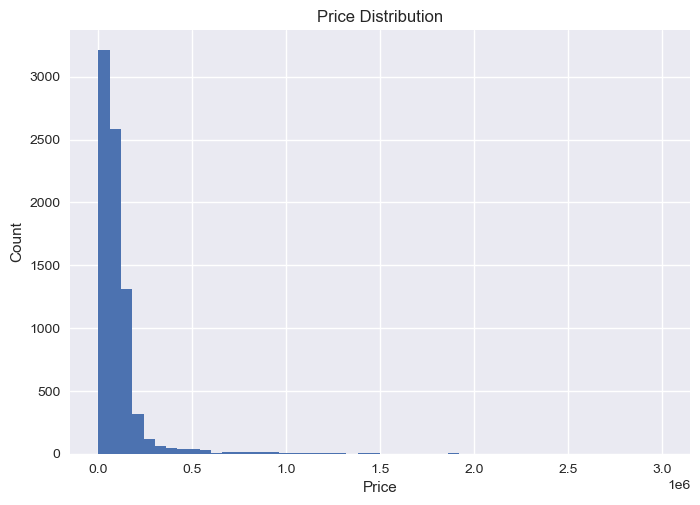

In [96]:
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [97]:
# Which brands have the most bike listings?

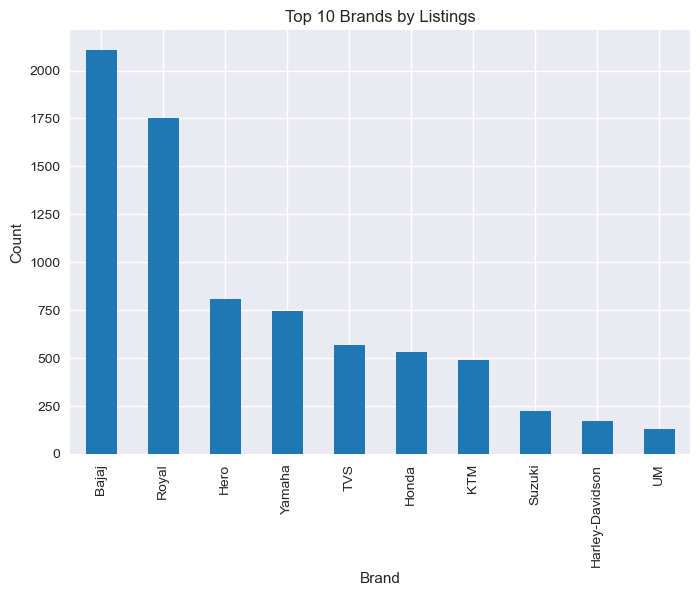

In [98]:
df['brand'].value_counts().head(10).plot(kind = 'bar', color='#1f77b4')
plt.title("Top 10 Brands by Listings")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()


In [99]:
# How does bike age affect price?

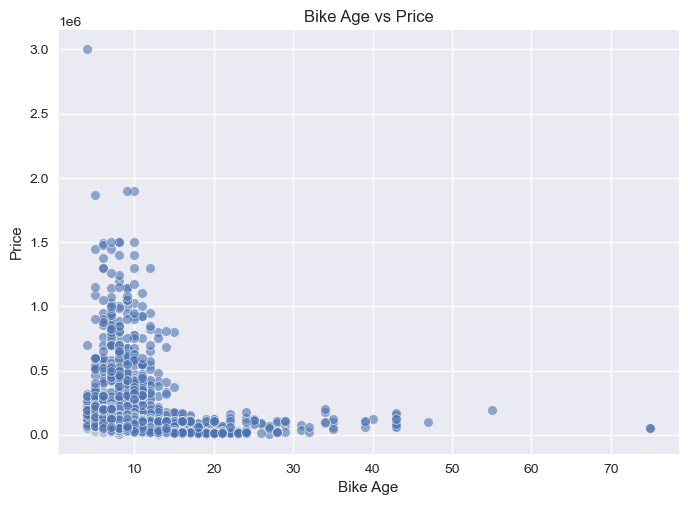

In [100]:
sns.scatterplot(x = df['bike_age'] , y = df['price'], alpha=0.6)
plt.title("Bike Age vs Price")
plt.xlabel("Bike Age")
plt.ylabel("Price")
plt.show()

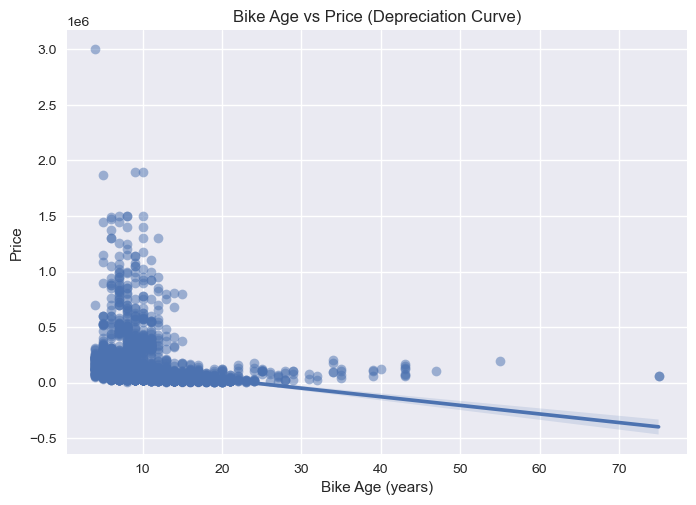

In [101]:
sns.regplot(
    x='bike_age',
    y='price',
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title('Bike Age vs Price (Depreciation Curve)')
plt.xlabel('Bike Age (years)')
plt.ylabel('Price')
plt.show()

# The regression line shows a negative relationship between bike age and price, confirming depreciation.The price drops sharply during the initial 3–4 years, after which depreciation becomes gradual.

In [102]:
# What is the mileage distribution?

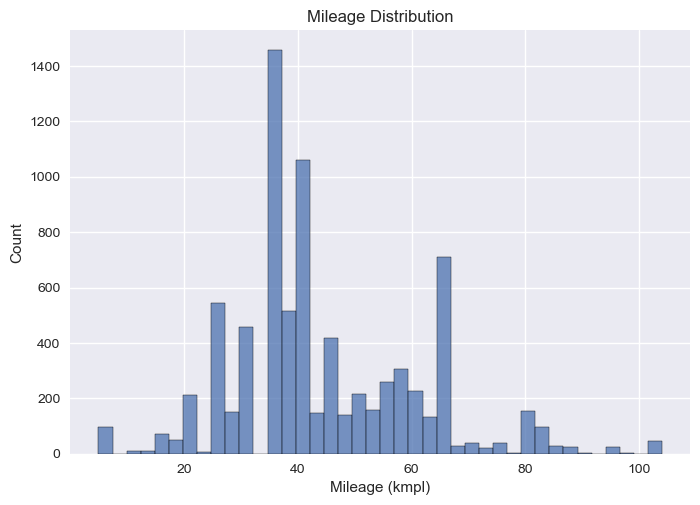

In [103]:
sns.histplot(df['mileage'], bins = 40)
plt.title("Mileage Distribution")
plt.xlabel("Mileage (kmpl)")
plt.ylabel("Count")
plt.show()

In [104]:
# How does engine capacity (CC) affect price?

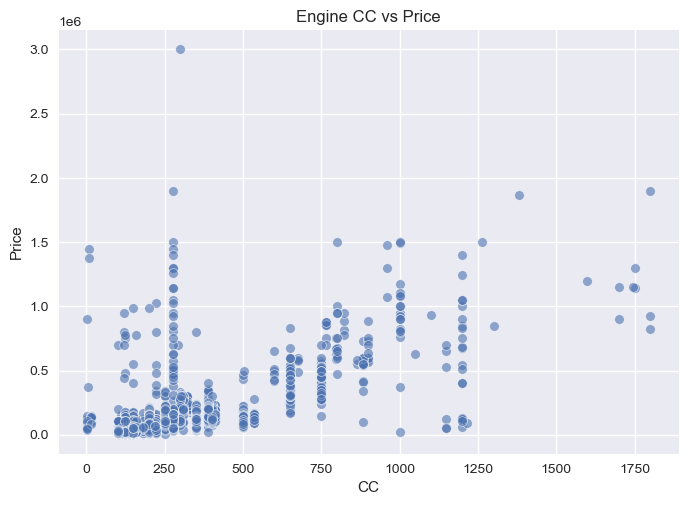

In [105]:
sns.scatterplot(x = df['cc'] , y = df['price'], alpha=0.6)
plt.title("Engine CC vs Price")
plt.xlabel("CC")
plt.ylabel("Price")
plt.show()

In [106]:
# Which brands have the highest average resale price?

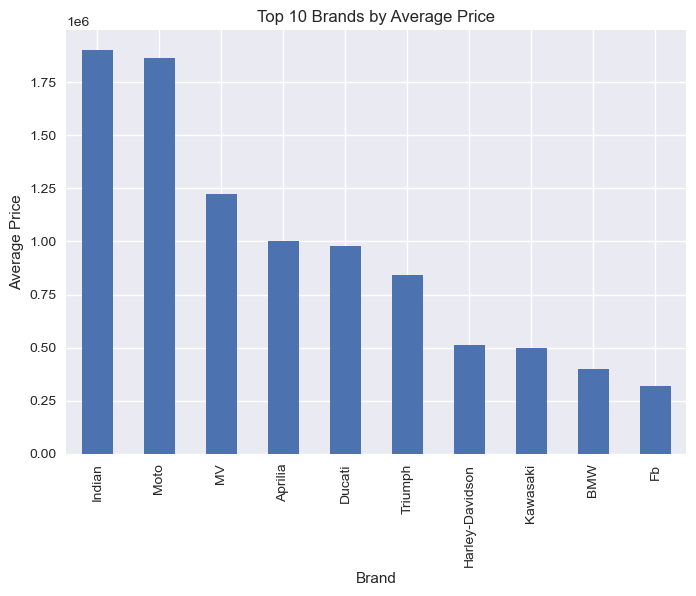

In [107]:
df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Brands by Average Price")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.show()

In [108]:
# How do kilometers driven affect price?

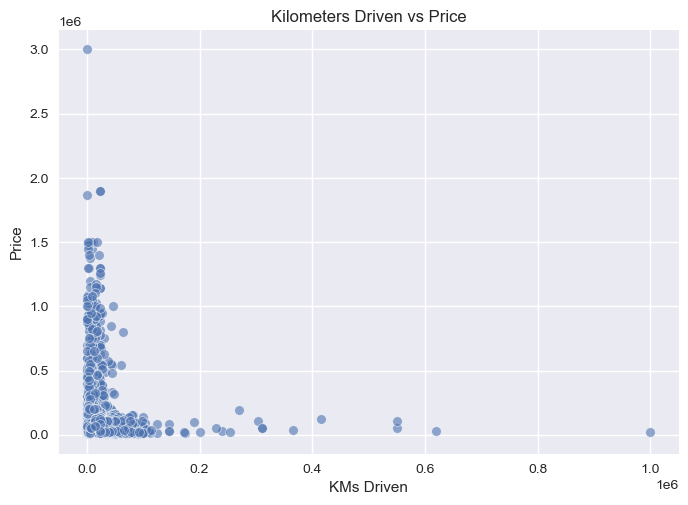

In [109]:
sns.scatterplot(x = df['kms_driven'], y = df['price'], alpha=0.6)
plt.title("Kilometers Driven vs Price")
plt.xlabel("KMs Driven")
plt.ylabel("Price")
plt.show()

In [110]:
# What is the distribution of owner types?

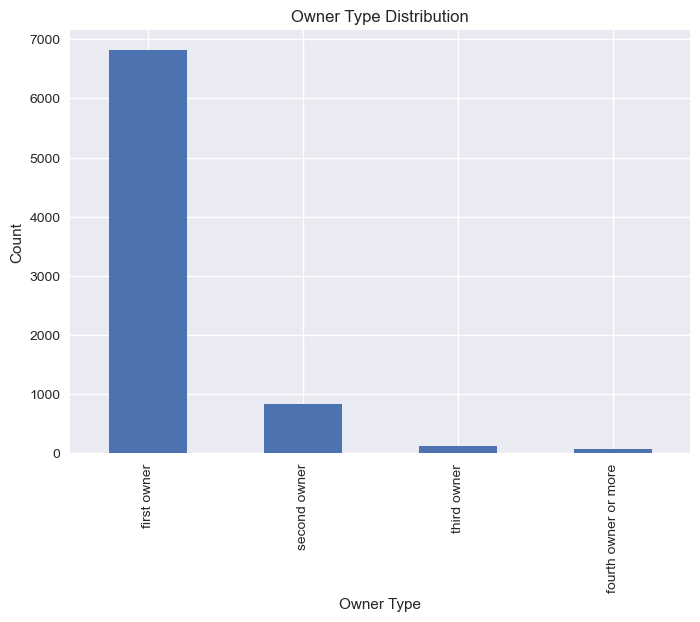

In [111]:
df['owner'].value_counts().plot(kind='bar')
plt.title("Owner Type Distribution")
plt.xlabel("Owner Type")
plt.ylabel("Count")
plt.show()

In [112]:
# Top 10 locations by listings

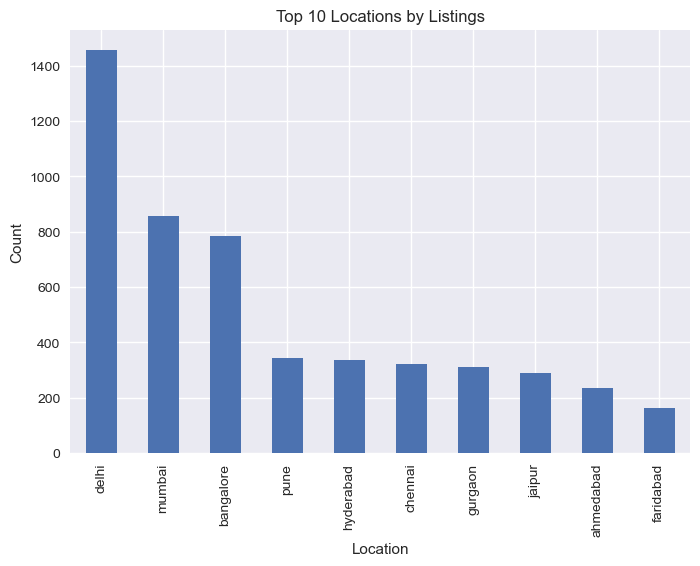

In [113]:
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Locations by Listings")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

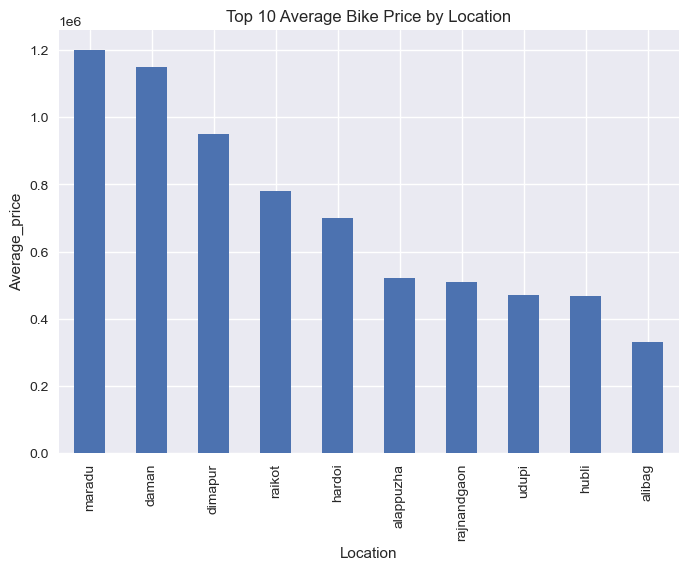

In [114]:
df.groupby('location')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Average Bike Price by Location")
plt.xlabel("Location")
plt.ylabel("Average_price")
plt.show()

In [115]:
#  Power vs Price

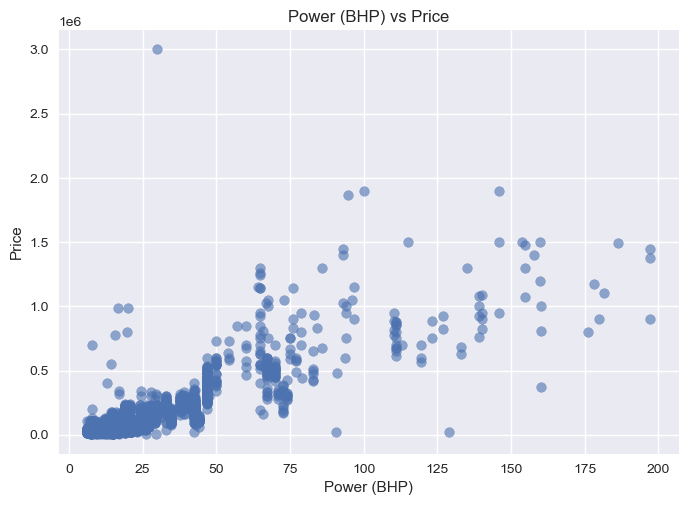

In [116]:
plt.scatter(df['power'], df['price'] , alpha=0.6)
plt.title("Power (BHP) vs Price")
plt.xlabel("Power (BHP)")
plt.ylabel("Price")
plt.show()

In [117]:
# Mileage vs Pric

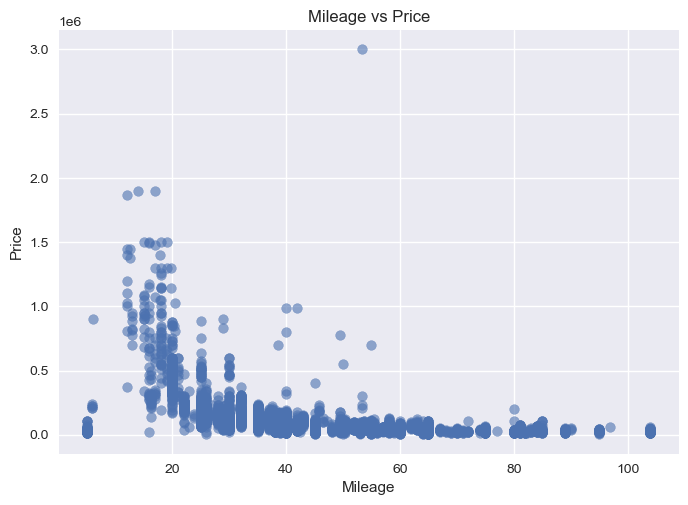

In [118]:
plt.scatter(df['mileage'], df['price'] , alpha=0.6)
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

detect outlier

In [119]:
df2 = pd.read_csv('cleaned_data.csv')

In [120]:
# detect and remove price_outlier

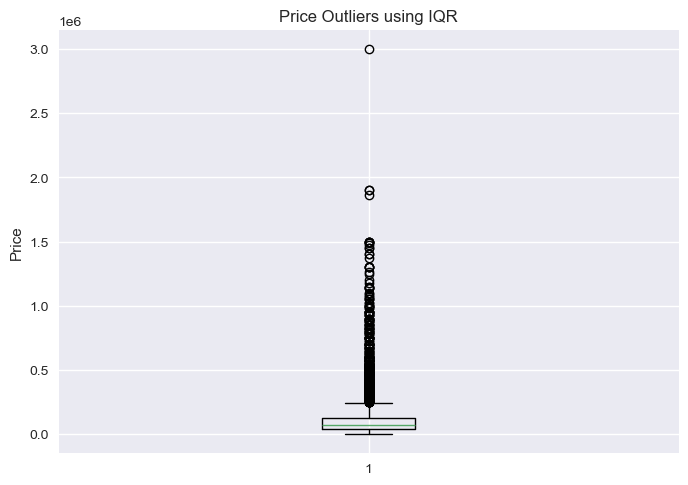

In [121]:
plt.boxplot(df2['price'])
plt.title("Price Outliers using IQR")
plt.ylabel("Price")
plt.show()

In [122]:
def remove_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    clean_data = data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]
    
    return clean_data

In [123]:
no_price_outlier = remove_iqr_outliers(df2,'price')

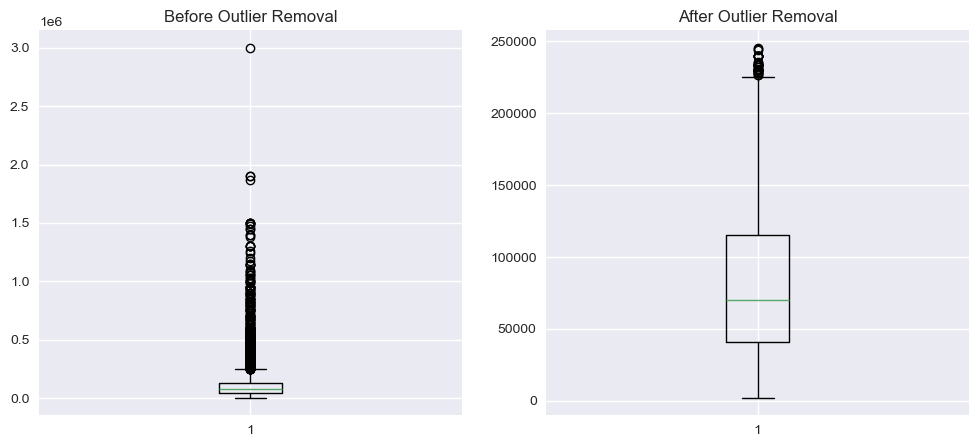

In [124]:
# BEFORE vs AFTER
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].boxplot(df2['price'])
ax[0].set_title("Before Outlier Removal")

ax[1].boxplot(no_price_outlier['price'])
ax[1].set_title("After Outlier Removal")

plt.show()


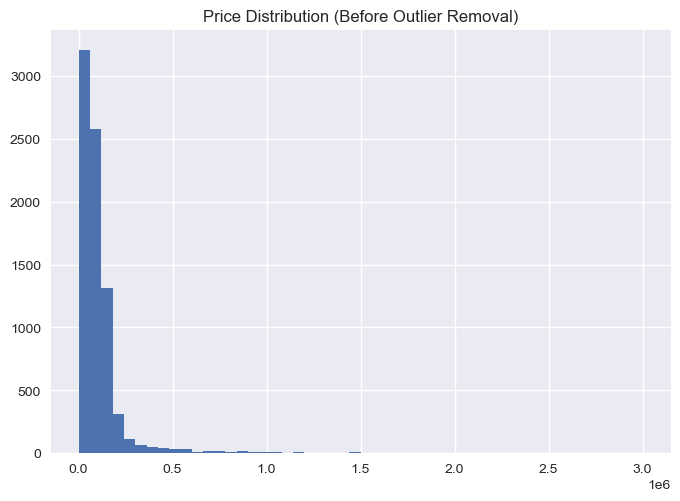

In [125]:
#before removing outlier
plt.hist(df['price'], bins=50)
plt.title("Price Distribution (Before Outlier Removal)")
plt.show()

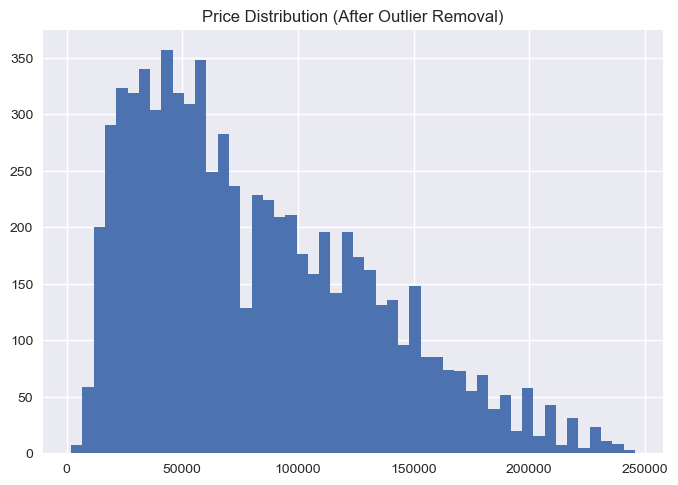

In [126]:
# after removing outliers
plt.hist(no_price_outlier['price'], bins=50)
plt.title("Price Distribution (After Outlier Removal)")
plt.show()

In [127]:
# High KMs but High Price

In [128]:
No_high_km_high_price = df2[~((df2['kms_driven'] > df2['kms_driven'].quantile(0.90)) & (df2['price'] > df2['price'].quantile(0.75)))]

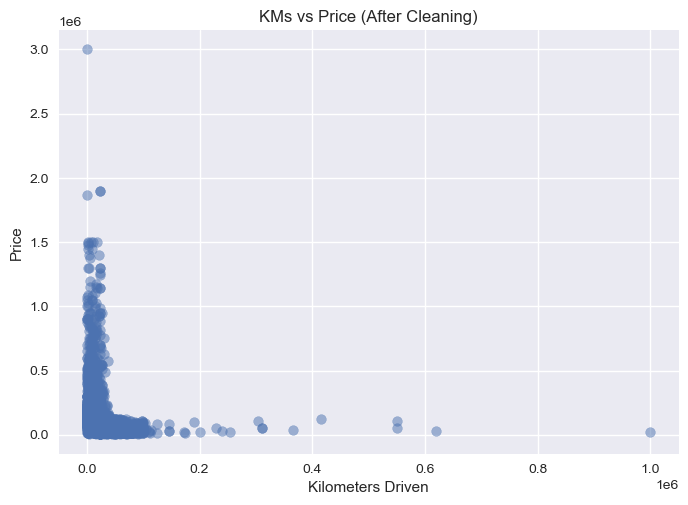

In [129]:
# High KMs but High Price
plt.figure()
plt.scatter(No_high_km_high_price['kms_driven'], No_high_km_high_price['price'], alpha=0.5)
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")
plt.title("KMs vs Price (After Cleaning)")
plt.show()


In [130]:
# High Price but Low CC

In [131]:
No_High_Price_Low_CC = df2[~((df2['cc'] < 200) & (df2['price'] > df2['price'].quantile(0.90)))]

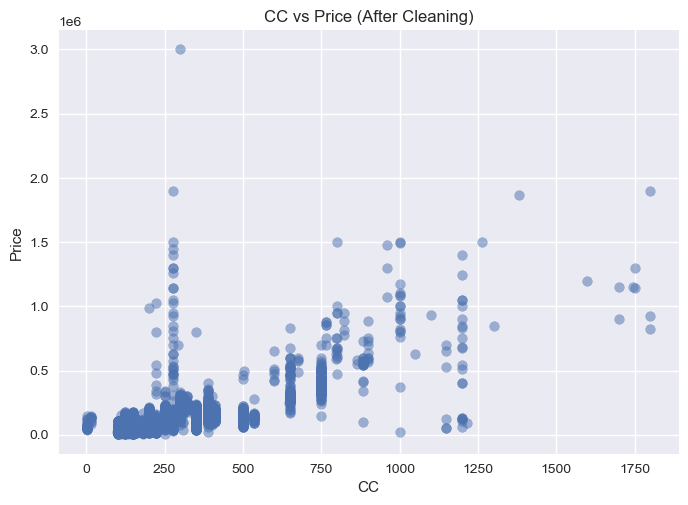

In [132]:
plt.scatter(No_High_Price_Low_CC['cc'], No_High_Price_Low_CC['price'], alpha=0.5)
plt.xlabel("CC")
plt.ylabel("Price")
plt.title("CC vs Price (After Cleaning)")
plt.show()

In [133]:
# Segment by CC RANGE
def cc_segment(cc):
    if cc <= 150:
        return "Commuter"
    elif cc <= 400:
        return "Mid-range"
    else:
        return "Premium"

df2['cc_segment'] = df2['cc'].apply(cc_segment)


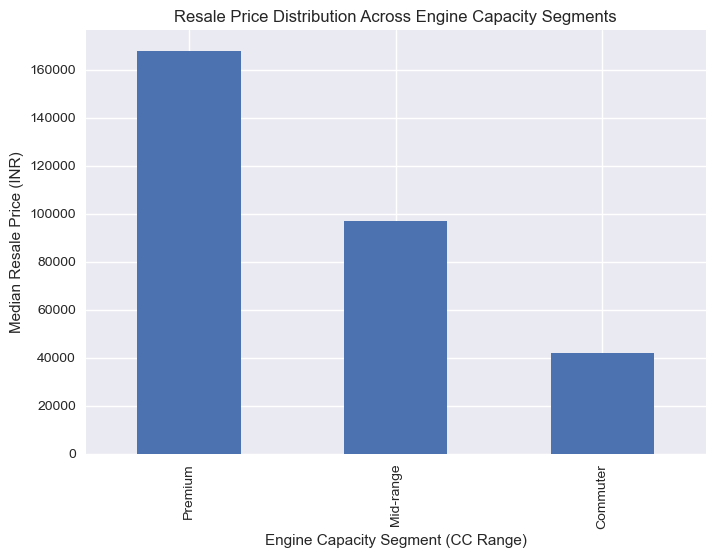

In [134]:
df2.groupby('cc_segment')['price'].median().sort_values(ascending=False).plot(kind='bar')
plt.title("Resale Price Distribution Across Engine Capacity Segments")
plt.xlabel("Engine Capacity Segment (CC Range)")
plt.ylabel("Median Resale Price (INR)")
plt.show()

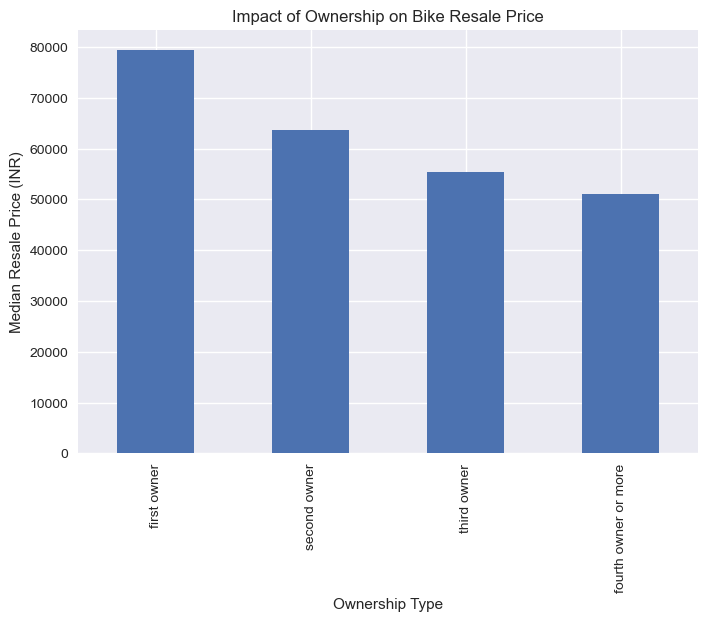

In [135]:
# Segment by OWNER TYPE
df2.groupby('owner')['price'].median().sort_values(ascending=False).plot(kind = 'bar')
plt.title("Impact of Ownership on Bike Resale Price")
plt.xlabel("Ownership Type")
plt.ylabel("Median Resale Price (INR)")
plt.show()

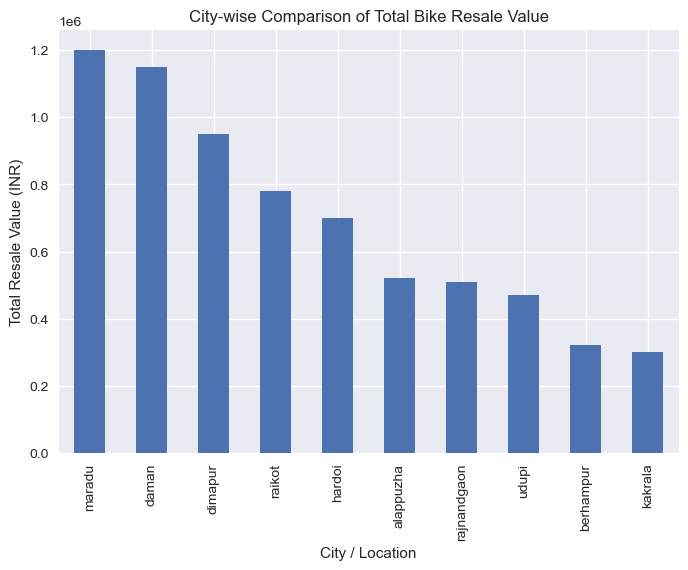

In [136]:
# Segment by LOCATION (City-wise Analysis)
df2.groupby('location')['price'].median().sort_values(ascending=False).head(10).plot(kind = 'bar')
plt.title("City-wise Comparison of Total Bike Resale Value")
plt.xlabel("City / Location")
plt.ylabel("Total Resale Value (INR)")
plt.show()

In [137]:
# In this EDA, I explored the used bike dataset and prepared it for modeling. I cleaned key numerical features such as kms_driven, mileage, and power, removed or treated inconsistent and missing values, and converted text-based columns into proper numeric formats. Categorical variables like brand, model, and ownership were inspected for cardinality and data quality.

# From the visual analysis and basic statistics, I observed that bike price tends to increase with engine power and mileage (to a point) and decrease with higher kms_driven and older model years. Certain brands and models clearly sit in higher or lower price segments. A few extreme outliers in price and kilometers were identified and handled to reduce their impact on later modeling.

# Overall, the dataset is now reasonably clean, key patterns and relationships are understood, and the features are in a suitable form to proceed with feature engineering and building machine learning models to predict bike prices.

Model Building – Future Work

In [138]:
df.corr(numeric_only=True)

,model_year,kms_driven,mileage,power,price,cc,bike_age,price_per_cc,price_per_km,power_to_cc
model_year,1.000000,-0.275397,-0.170531,0.147847,0.223256,0.107655,-1.000000,0.073004,0.020213,0.045756
kms_driven,-0.275397,1.000000,0.126380,-0.143511,-0.183675,-0.142450,0.275397,-0.042265,-0.019822,-0.024629
mileage,-0.170531,0.126380,1.000000,-0.552696,-0.459337,-0.587185,0.170531,-0.031672,-0.036248,-0.016238
power,0.147847,-0.143511,-0.552696,1.000000,0.829680,0.723044,-0.147847,0.208074,0.170027,0.186944
price,0.223256,-0.183675,-0.459337,0.829680,1.000000,0.658391,-0.223256,0.191421,0.098306,0.133576
cc,0.107655,-0.142450,-0.587185,0.723044,0.658391,1.000000,-0.107655,-0.058386,0.013165,-0.071213
bike_age,-1.000000,0.275397,0.170531,-0.147847,-0.223256,-0.107655,1.000000,-0.073004,-0.020213,-0.045756
price_per_cc,0.073004,-0.042265,-0.031672,0.208074,0.191421,-0.058386,-0.073004,1.000000,0.575152,0.976461
price_per_km,0.020213,-0.019822,-0.036248,0.170027,0.098306,0.013165,-0.020213,0.575152,1.000000,0.684871
power_to_cc,0.045756,-0.024629,-0.016238,0.186944,0.133576,-0.071213,-0.045756,0.976461,0.684871,1.000000


In [139]:
# 1. Load the dataset
data_frame = pd.read_csv('cleaned_data.csv')

In [140]:
# 2. Create the stratified test set
# Create power bins
data_frame["power_bin"] = pd.cut(
    data_frame["power"],
    bins=[0, 20, 40, 60, 80, 120, 200, float("inf")],
    labels=["Very Low", "Low", "Medium", "High", "Very High", "Premium", "Super Premium"]
)


In [141]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [142]:
for train_idx , test_idx in split.split(data_frame, data_frame['power_bin']):
    train_data = data_frame.iloc[train_idx].drop('power_bin', axis = 1)
    test_data = data_frame.iloc[test_idx].drop('power_bin', axis = 1)

In [143]:
# we will work on the copy of the train data set 
bike_data = train_data.copy()

In [144]:
# 3.separate featurres and labels
bike_features =  bike_data.drop('price', axis =1)
bike_label = bike_data['price'].copy()

In [145]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6285 entries, 7213 to 498
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model_name    6285 non-null   object 
 1   model_year    6285 non-null   int64  
 2   kms_driven    6285 non-null   float64
 3   owner         6285 non-null   object 
 4   location      6285 non-null   object 
 5   mileage       6285 non-null   float64
 6   power         6285 non-null   float64
 7   price         6285 non-null   float64
 8   brand         6285 non-null   object 
 9   cc            6285 non-null   int64  
 10  bike_age      6285 non-null   int64  
 11  price_per_cc  6285 non-null   float64
 12  price_per_km  6285 non-null   float64
 13  power_to_cc   6285 non-null   float64
dtypes: float64(7), int64(3), object(4)
memory usage: 736.5+ KB


In [146]:
# 4. separate numerical and categorical columns
num_attributes = ['model_year' , 'kms_driven', 'mileage', 'power', 'cc', 'bike_age', 'price_per_cc', 'price_per_km', 'power_to_cc']
cat_attributes = ['model_name', 'owner' , 'location' ,'brand']

In [147]:
# 5. Lets make pipline

In [148]:
# For numerical columns
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scaler" , StandardScaler())
])

In [149]:
# For categorical columns
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

In [150]:
# Constuct full pipline
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attributes),
    ("cat" , cat_pipeline, cat_attributes)
])

In [151]:
bike_preperd = full_pipeline.fit_transform(bike_features)

In [152]:
# Train the model

In [153]:
test_data_features = test_data.drop('price', axis =1)
test_data_label = test_data['price'].copy()

📊 Model Comparison & Evaluation

Multiple regression models were trained and evaluated using consistent preprocessing, train–test splits, and evaluation metrics. Models were compared using RMSE, MAE, and R² to ensure a fair and objective selection of the final model.

In [154]:
models = {
    "Linear Regression" : Pipeline([
          ("preprocessing", full_pipeline),
          ("lr", LinearRegression())    
    ]),

    "Ridge Regression" : Pipeline([
          ("preprocessing", full_pipeline),
          ("lr", Ridge())    
    ]),

    "Decision Tree" : Pipeline([
          ("preprocessing", full_pipeline),
          ("lr", DecisionTreeRegressor(random_state=42))    
    ]),

    "Random Forest" : Pipeline([
          ("preprocessing", full_pipeline),
          ("lr", RandomForestRegressor(random_state=42))    
    ]),
}

In [155]:
def evalute_model(name, model, train_features, train_label, test_features, test_label):
    model.fit(train_features,train_label)
    pred = model.predict(test_features)
    return {
        "Model" : name,
        "MAE" : mean_absolute_error(test_label, pred),
        "RMSE" : root_mean_squared_error(test_label, pred),
        "R2" : r2_score(test_label, pred)
    }
    

In [156]:
result = []

for name, model in models.items():
    result.append(
        evalute_model(name, model, bike_features, bike_label, test_data_features, test_data_label))

In [157]:
result_df = pd.DataFrame(result).sort_values(by="RMSE")
print(result_df)

               Model           MAE          RMSE        R2
3      Random Forest   5518.601461  35993.664028  0.933673
2      Decision Tree   6370.857653  41177.200160  0.913193
0  Linear Regression  19976.292355  63867.982471  0.791164
1   Ridge Regression  18168.109954  68156.592136  0.762176


Final Model Selection

Tree-based models significantly outperformed linear and regularized regression models, indicating strong non-linear relationships in the data.
While the Decision Tree Regressor achieved the lowest RMSE and highest R², Random Forest was selected as the final model due to its superior generalization ability and robustness against overfitting.
Linear and Ridge Regression served as baselines and demonstrated underfitting, reinforcing the need for ensemble-based approaches.

In [158]:
full_model = Pipeline([
    ("preprocessing", full_pipeline),
    ("rf", RandomForestRegressor(random_state=42))
])

In [159]:
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt", "log2"]
}

In [160]:
grid_search = GridSearchCV(
    full_model,
    param_grid,
    cv = 5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2 
)

In [161]:
grid_search.fit(bike_features, bike_label)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['model_year',
                                                                          'kms_driven',
                                                                          'mileage',
                                                                          'power',
                                                                          'cc',
                                                                          'bike_age',
                                                                          'price_per_cc',
                                                                          'price_per_km',
                                                                          'power_to_cc']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['model_name',
                                                                          'owner',
                                                                          'location',
                                                                          'brand'])])),
                                       ('rf',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20],
                         'rf__max_features': ['sqrt', 'log2'],
                         'rf__min_samples_leaf': [1, 2],
                         'rf__min_samples_split': [2, 5],
                         'rf__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [162]:
print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


In [163]:
print("Best CV RMSE:")
print(-grid_search.best_score_)


Best CV RMSE:
52787.571188462876


In [164]:
best_model = grid_search.best_estimator_

In [165]:
predicted_price = best_model.predict(test_data_features)

In [166]:
# predicted_price = randomForest_model.predict(test_prepered)

In [167]:
rmse = root_mean_squared_error(test_data_label, predicted_price)
mae  = mean_absolute_error(test_data_label, predicted_price)
r2   = r2_score(test_data_label, predicted_price)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 41116.56558181403
MAE : 12063.943486285252
R2  : 0.9134488103639795


<Axes: xlabel='price'>

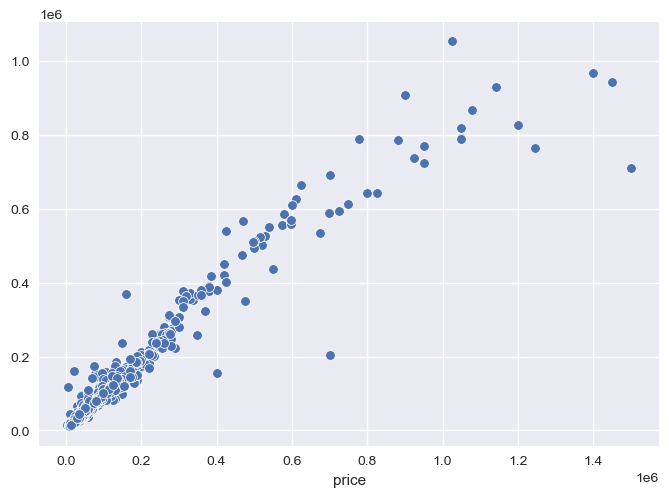

In [168]:
sns.scatterplot(x = test_data_label, y = predicted_price)

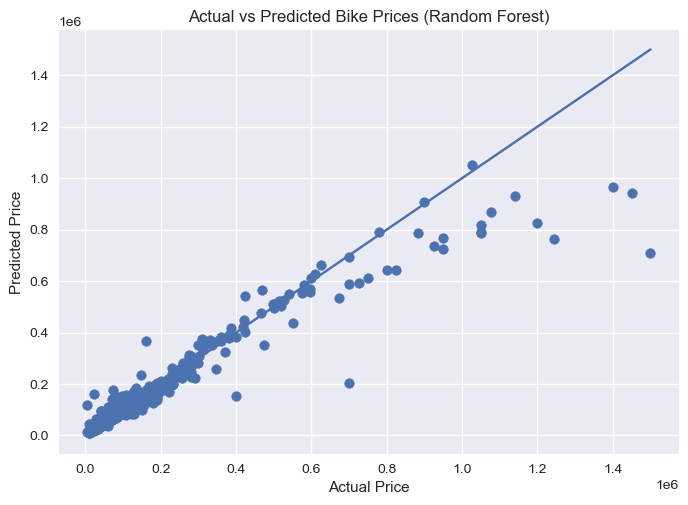

In [169]:
# Predictions from final model
y_true = test_data_label
y_pred = predicted_price

plt.figure()
plt.scatter(y_true, y_pred)
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()]
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Bike Prices (Random Forest)")
plt.show()


Feature Importance

In [170]:
rf_model = best_model.named_steps["rf"]

feature_names = best_model.named_steps["preprocessing"].get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values(by="importance", ascending=False)
)

feature_importance_df.head(10)


,feature,importance
3,num__power,0.141385
2,num__mileage,0.098275
4,num__cc,0.097847
7,num__price_per_km,0.093053
6,num__price_per_cc,0.089479
8,num__power_to_cc,0.058584
1,num__kms_driven,0.038757
2106,cat__brand_Harley-Davidson,0.030678
2122,cat__brand_Triumph,0.029658
0,num__model_year,0.021154


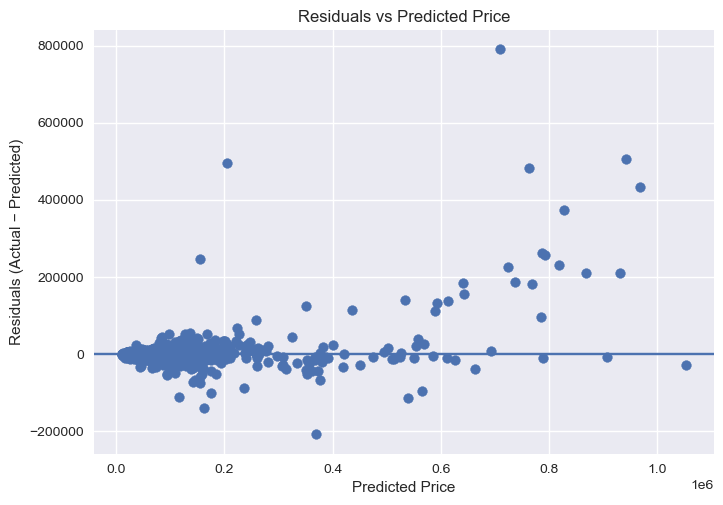

In [171]:
residuals = y_true - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residuals vs Predicted Price")
plt.show()


In [172]:
# Actual vs Predicted:

# “Most predictions align closely with actual prices, indicating strong model accuracy. Slight dispersion at higher prices is expected due to limited data in premium segments.”

# Residual Plot:

# “Residuals are randomly distributed around zero, suggesting no major systematic bias in predictions.”

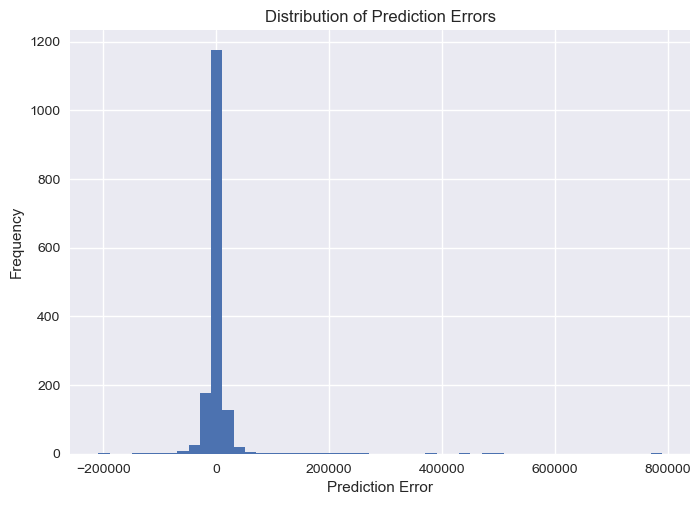

In [173]:
plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()
